In [ ]:
# 필요한 패키지 설치
# !pip install missingno
import missingno as msno 
# missingno는 **결측치(missing values)**를 시각적으로 파악하고 분석할 수 있도록 도와주는 파이썬 데이터 시각화 도구
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
plt.rcParams['figure.dpi'] = 300

In [3]:
# 데이터 불러오기
# https://www.kaggle.com/datasets/sewonghwang/daily-bike-sharing
df = pd.read_csv("../../main/datasets/bike_sharing_daily.csv")

# 데이터 샘플 확인
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331.0,654.0,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131.0,670.0,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,NaN,0.437273,0.248309,120.0,1229.0,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108.0,1454.0,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82.0,1518.0,1600


In [4]:
# 각 컬럼의 속성 및 결측값 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        714 non-null    float64
 10  atemp       707 non-null    float64
 11  hum         706 non-null    float64
 12  windspeed   718 non-null    float64
 13  casual      720 non-null    float64
 14  registered  720 non-null    float64
 15  cnt         731 non-null    int64  
dtypes: float64(6), int64(9), object(1)
memory usage: 91.5+ KB


In [7]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,714.000000,707.000000,706.000000,718.000000,720.000000,720.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.497644,0.474674,0.628691,0.191136,848.102778,3658.512500,4505.255814
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.182952,0.162837,0.142652,0.077166,686.293614,1554.760481,1935.491354
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.341667,0.337842,0.522708,0.135111,314.750000,2499.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.502989,0.482942,0.630000,0.181598,717.000000,3660.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.656667,0.610803,0.731042,0.234156,1095.500000,4753.250000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [8]:
# 각 컬럼의 왜도 확인
df.select_dtypes(include='number').skew()

instant       0.000000
season       -0.000384
yr           -0.002742
mnth         -0.008149
holiday       5.654224
weekday       0.002742
workingday   -0.793147
weathersit    0.957385
temp         -0.069778
atemp        -0.132665
hum          -0.080615
windspeed     0.667473
casual        1.264252
registered    0.051406
cnt          -0.043808
dtype: float64

In [9]:
# 각 컬럼의 첨도 확인
df.select_dtypes(include='number').kurtosis()

instant       -1.200000
season        -1.342601
yr            -2.005487
mnth          -1.209112
holiday       30.052462
weekday       -1.254282
workingday    -1.374686
weathersit    -0.136467
temp          -1.107498
atemp         -0.980769
hum           -0.039245
windspeed      0.406159
casual         1.325395
registered    -0.708637
cnt           -0.816982
dtype: float64

In [5]:
# 결측값 수만 확인
df.isnull().sum()

instant        0
dteday         0
season         0
yr             0
mnth           0
holiday        0
weekday        0
workingday     0
weathersit     0
temp          17
atemp         24
hum           25
windspeed     13
casual        11
registered    11
cnt            0
dtype: int64

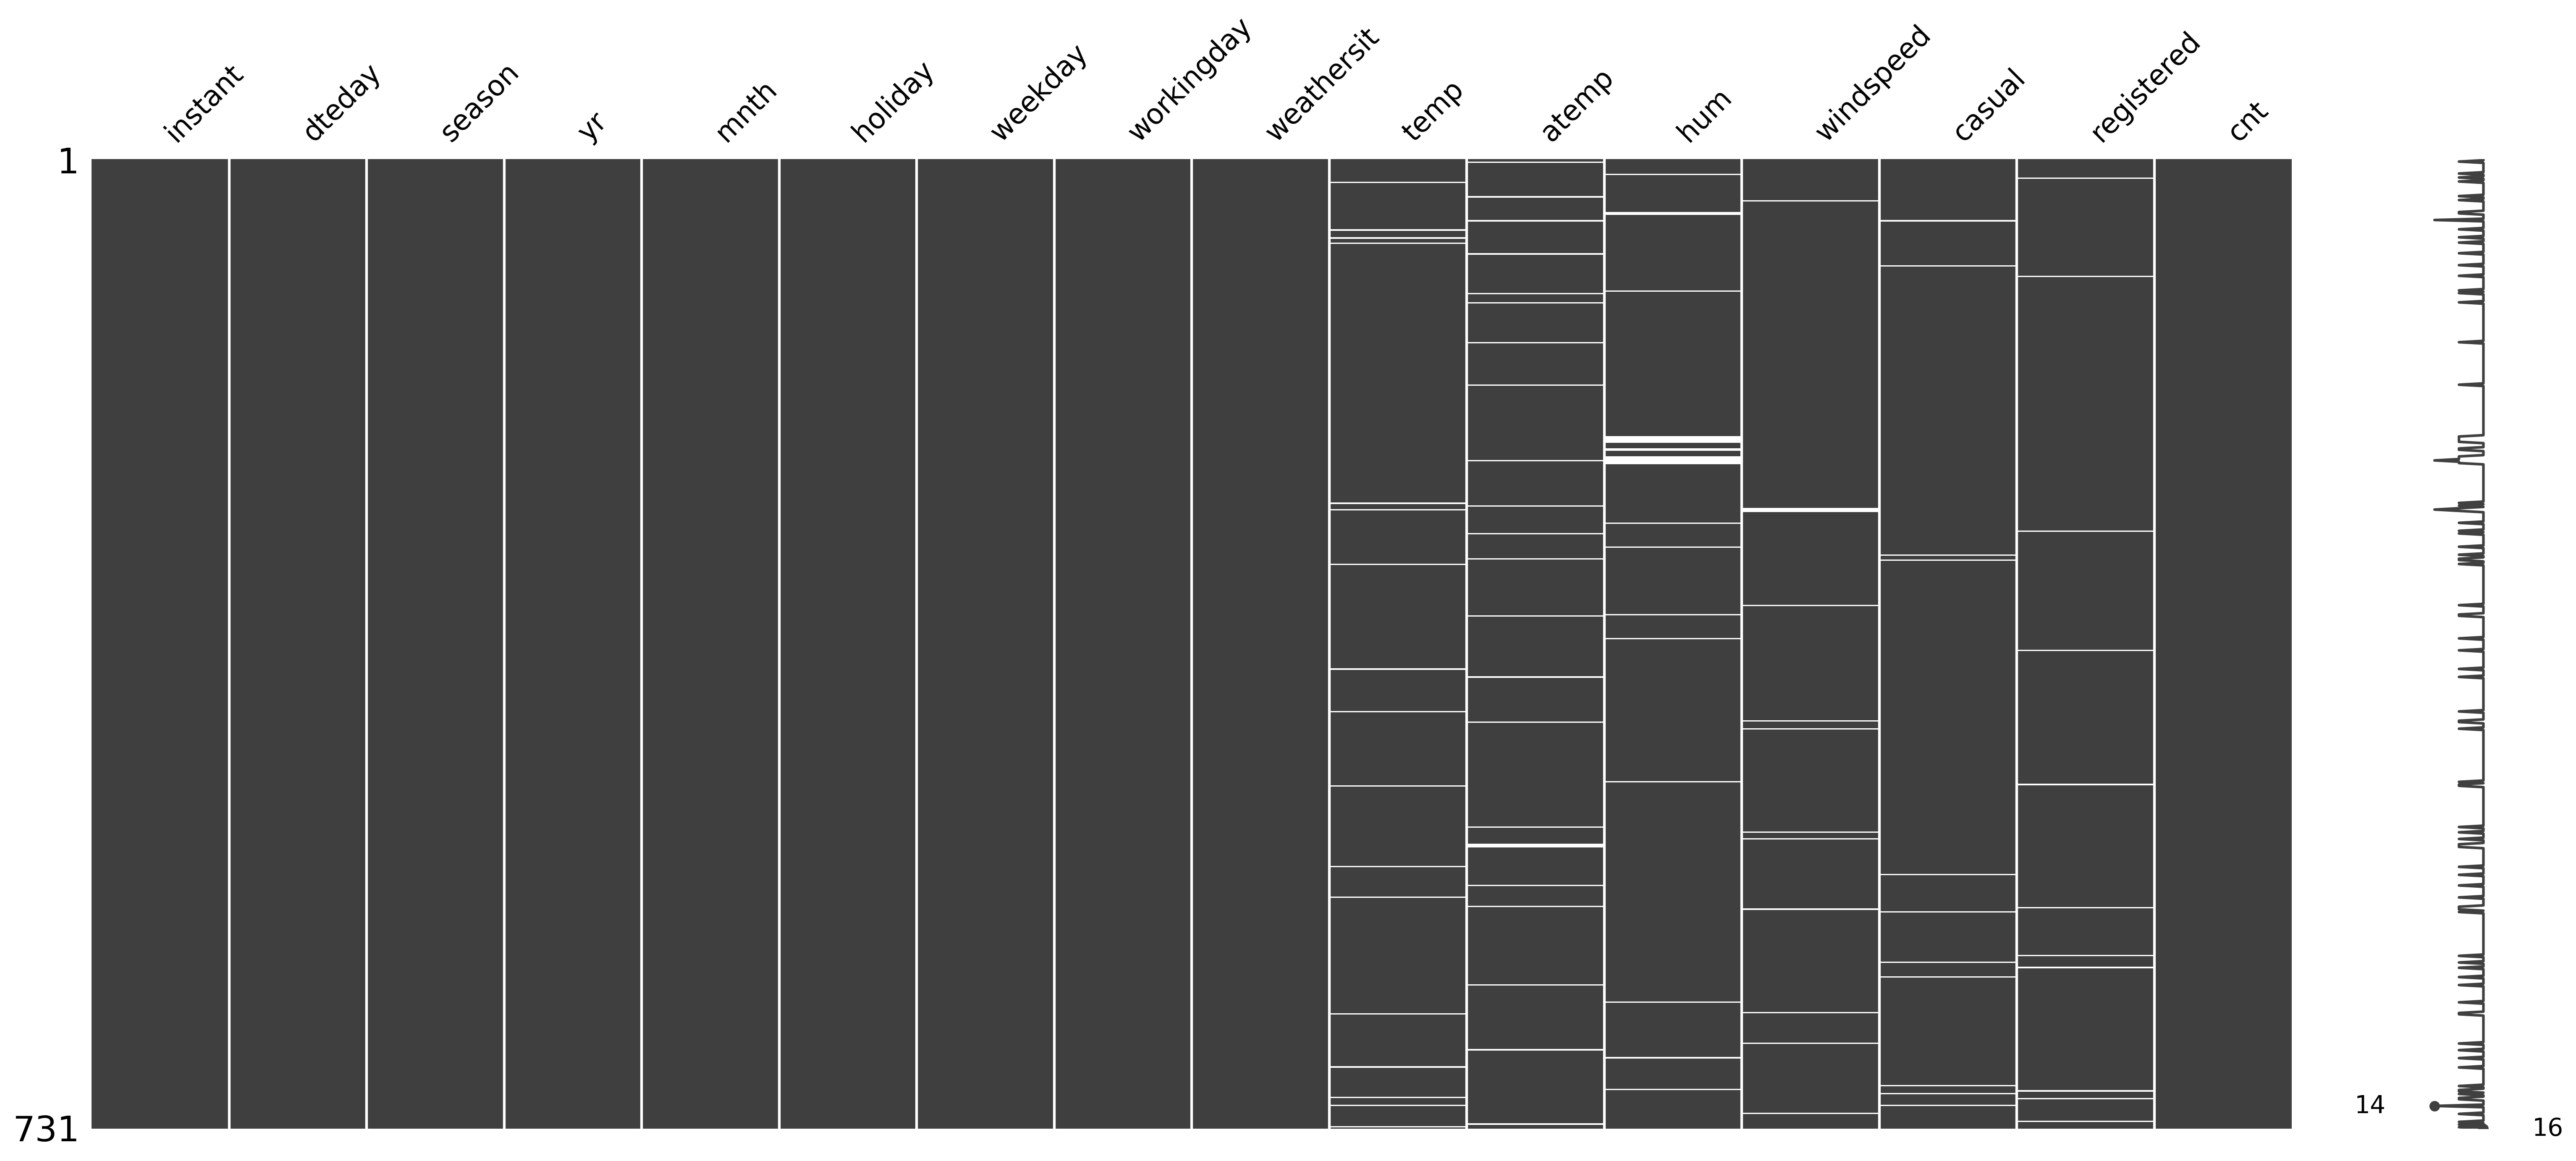

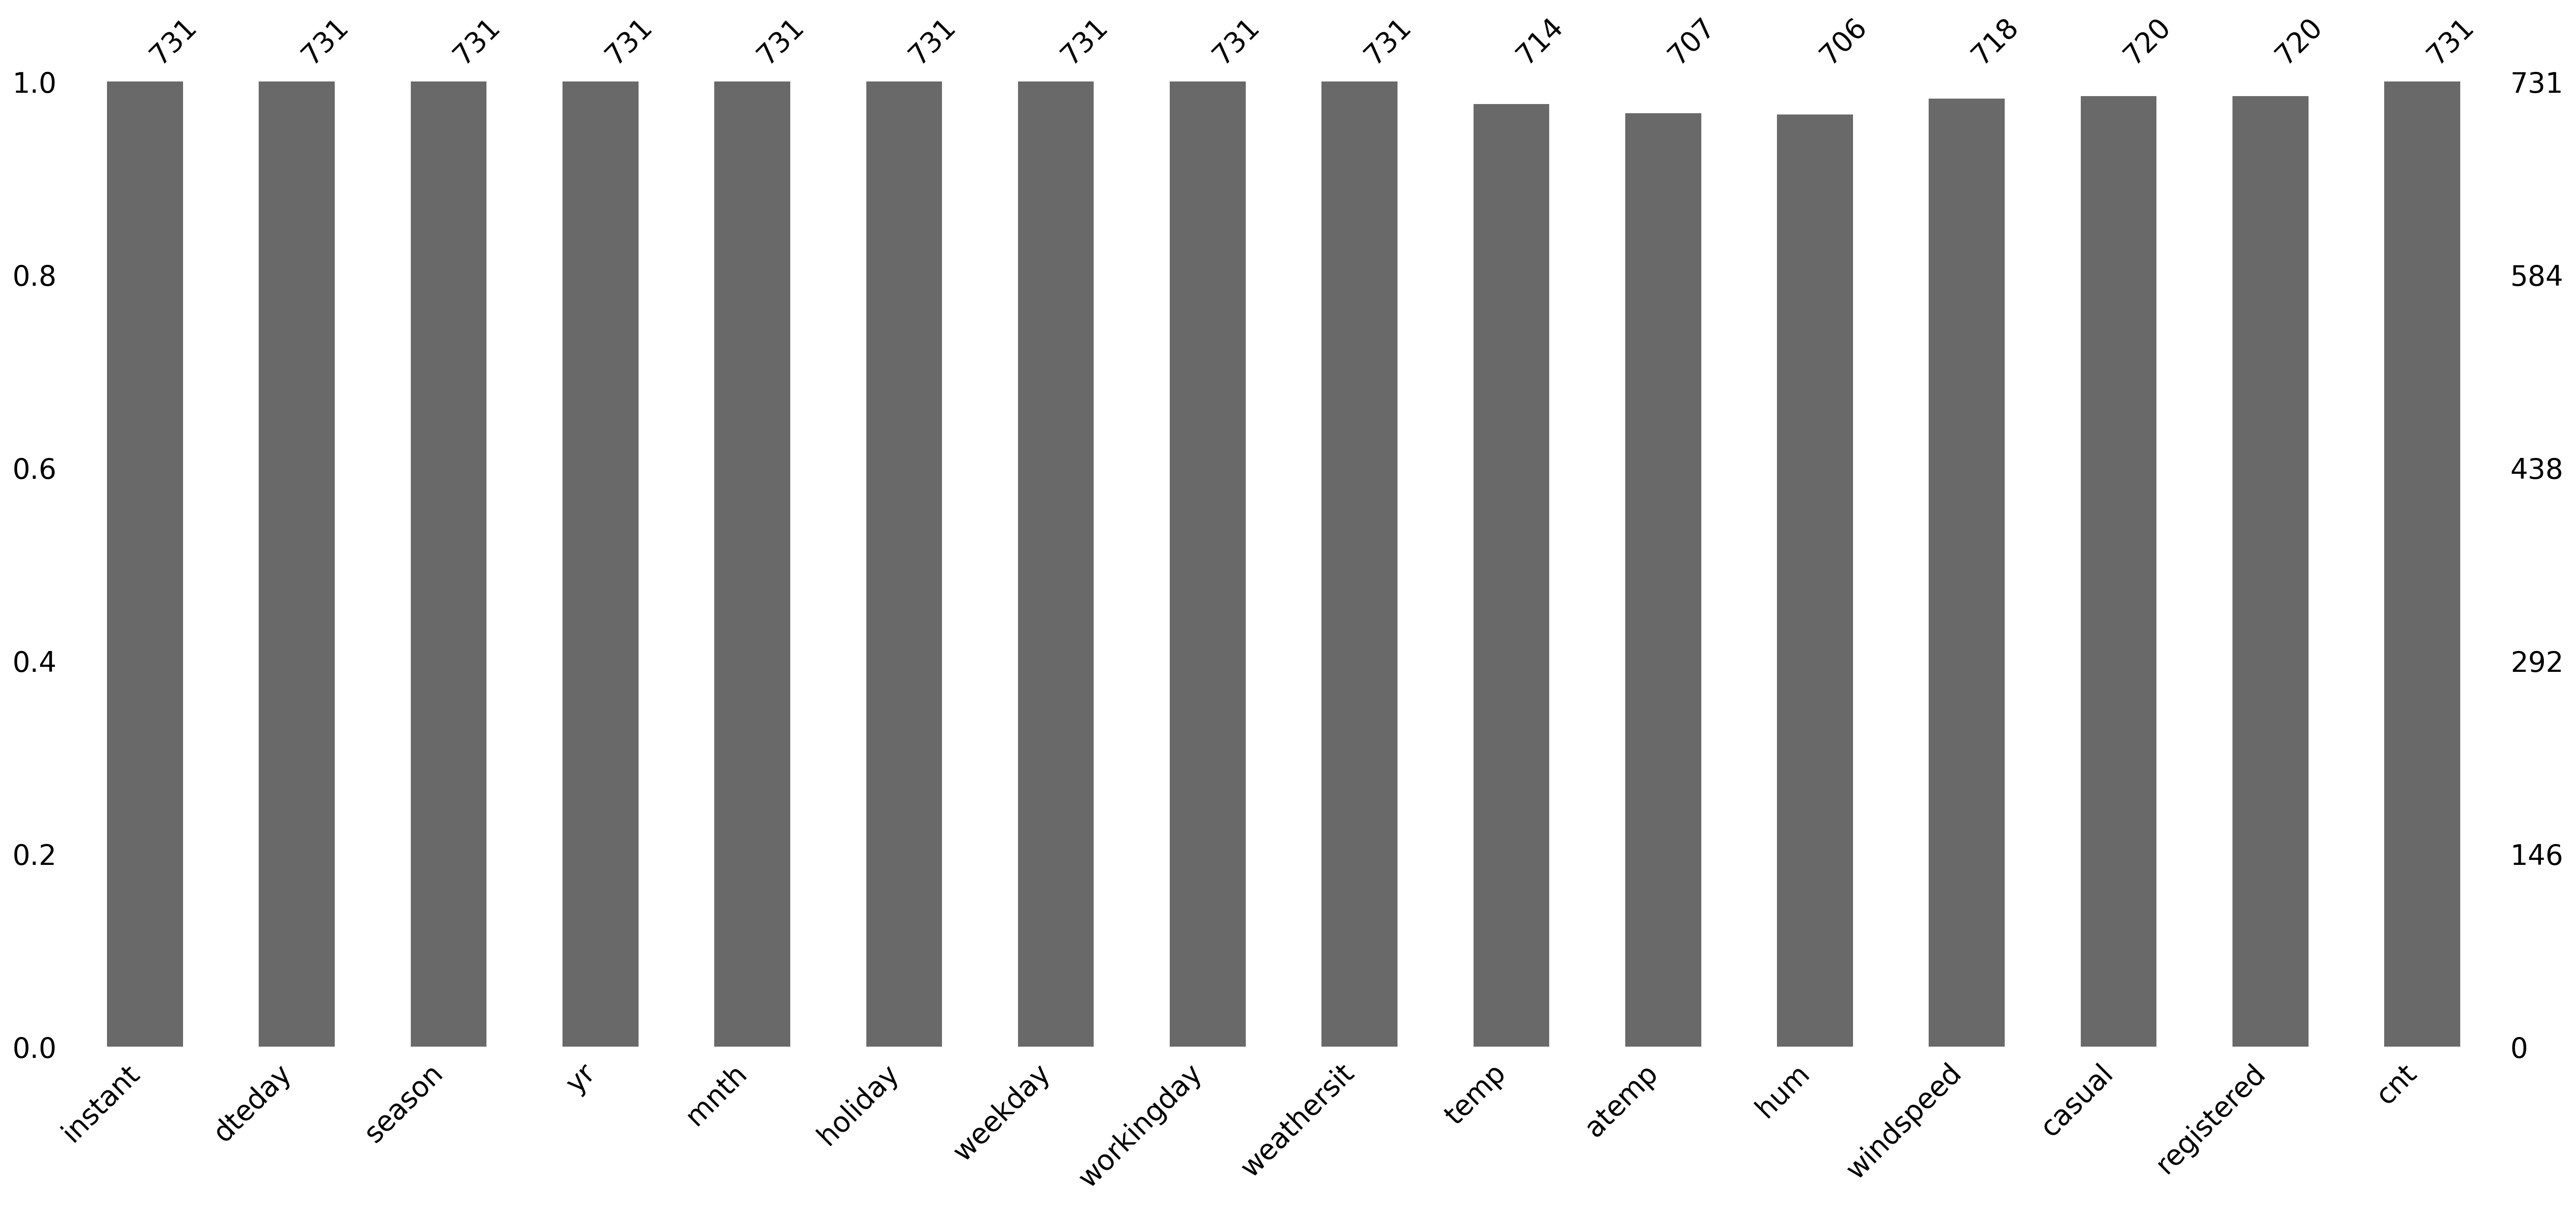

In [11]:
# 결측값 시각화 - 전체 컬럼의 결측값 시각화

# 결측값 영역 표시
msno.matrix(df)
plt.show()

# 결측값 막대 그래프
msno.bar(df)
plt.show()

In [ ]:
# 결측값이 아닌 빈 문자열이 있는지 확인

def is_emptystring(x):
    return x.eq('').any()

df.apply(lambda x:is_emptystring(x))

instant       False
dteday        False
season        False
yr            False
mnth          False
holiday       False
weekday       False
workingday    False
weathersit    False
temp          False
atemp         False
hum           False
windspeed     False
casual        False
registered    False
cnt           False
dtype: bool

In [13]:
# 결측값 표본 제거

# 모든 컬럼이 결측값인 행 제거
df_drop_all = df.dropna(how='all')

#  세개 이상의 컬럼이 결측값인 행 제거
df_drop_3 = df.dropna(thresh=3)

#  특정 컬럼(temp)이 결측값인 행 제거
df_drop_slt = df.dropna(subset=['temp'])

# 한 컬럼이라도 결측치가 있는 행 제거
df_drop_any = df.dropna(how='any')

df_drop_any.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [ ]:
# df.info()
df_drop_any.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     634 non-null    int64  
 1   dteday      634 non-null    object 
 2   season      634 non-null    int64  
 3   yr          634 non-null    int64  
 4   mnth        634 non-null    int64  
 5   holiday     634 non-null    int64  
 6   weekday     634 non-null    int64  
 7   workingday  634 non-null    int64  
 8   weathersit  634 non-null    int64  
 9   temp        634 non-null    float64
 10  atemp       634 non-null    float64
 11  hum         634 non-null    float64
 12  windspeed   634 non-null    float64
 13  casual      634 non-null    float64
 14  registered  634 non-null    float64
 15  cnt         634 non-null    int64  
dtypes: float64(6), int64(9), object(1)
memory usage: 84.2+ KB


In [ ]:
## 결측값 기본 대치 방법들

# 특정값(0)으로 대치 - 전체 컬럼
df_0_all = df.fillna(0)

# 특정값(0)으로 대치 - 컬럼 지정
df_0_slt = df.fillna({'temp':0})

# 평균값 대치 - 전체 컬럼
df_mean_all = df.fillna(df.mean(numeric_only=True))
# df_mean_all = df.fillna(df.select_dtypes(include='number').mean())

# 평균값 대치 - 컬럼 지정
df_mean_slt = df.fillna({'temp':df['temp'].mean()})

# 중앙값 대치 - 전체 컬럼
df_median_all = df.fillna(df.median(numeric_only=True))

# 중앙값 대치 - 컬럼 지정
df_median_slt = df.fillna({'temp':df['temp'].median()})

# 최빈값 대치 - 전체 컬럼
df_mode_all = df.fillna(df.mode())

# 최빈값 대치 - 컬럼 지정
df_mode_slt = df.fillna({'temp':df['temp'].mode()})

# 최댓값 대치 - 전체 컬럼: 각 컬럼의 최댓값으로 결측치를 채움
df_max_all = df.fillna(df.max())

# 최댓값 대치 - 컬럼 지정
df_max_slt = df.fillna({'temp':df['temp'].max()})

# 최솟값 대치 - 전체 컬럼: 각 컬럼의 최솟값으로 대체
df_min_all = df.fillna(df.min())

# 최솟값 대치 - 컬럼 지정
df_min_slt = df.fillna({'temp':df['temp'],'hum':df['hum'].min()})


df_min_slt.isnull().sum()

instant        0
dteday         0
season         0
yr             0
mnth           0
holiday        0
weekday        0
workingday     0
weathersit     0
temp          17
atemp         24
hum            0
windspeed     13
casual        11
registered    11
cnt            0
dtype: int64

In [ ]:
# 결측값 보간 대치 방법들

# 전 시점 값으로 대치 - 컬럼 지정
df1 = df.copy()
df1['temp'].fillna(method ='pad' ,inplace=True)

# 원본: 10, NaN, NaN, 20  
# → 채움: 10, 10, 10, 20


# 뒤 시점 값으로 대치 - 전체 컬럼
df.fillna(method ='bfill')

# 원본: 10, NaN, NaN, 20  
# → 채움: 10, 20, 20, 20

# 뒤 시점 값으로 대치 - 결측값 연속 한번만 대치
df.fillna(method='bfill', limit=1)

# 원본: 10, NaN, NaN, 20  
# → 채움: 10, 20, NaN, 20

# 보간법 함수 사용하여 대치 - 단순 순서 방식
ts_intp_linear = df.interpolate(method='values')

# 원본: 10, NaN, NaN, 16  
# → 채움: 10, 12, 14, 16

# 보간법 함수 사용하여 대치 - 시점 인덱스 사용

    # dteday 컬럼 시계열 객체 변환
df['dteday'] = pd.to_datetime(df['dteday'])

    # dteday 컬럼 인덱스 변경
df_i = df.set_index('dteday') 

    # 시점에 따른 보간법 적용
df_time = df_i.interpolate(method='time')

df_time.isnull().sum()

instant       0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [ ]:
#다중 대치(MICE) 

# dteday 컬럼 제거
df_dp = df.drop(['dteday'],axis=1)

# 다중 대치 알고리즘 설정
imputer = IterativeImputer(
    imputation_order='ascending',     # 결측치가 적은 컬럼부터 대치
    max_iter=10,                      # 최대 반복 횟수 (default는 10)
    random_state=42,                  # 랜덤성 고정
    n_nearest_features=5              # 예측에 사용할 인접 변수 수 제한 (성능 향상)
)

# 🔍 MICE (다중 대치)란?

# 결측치가 있는 컬럼을 하나씩 대상으로
# 나머지 컬럼들을 **입력 변수(X)**로 보고,
# 해당 컬럼을 **출력 변수(y)**로 가정하여 회귀모델을 훈련
# 예측값으로 결측치를 대치함
# 이를 여러 컬럼에 대해 순차적으로 반복 수행 (Chain)

# 다중 대치 적용
df_imputed = imputer.fit_transform(df_dp)

# 판다스 변환 및 컬럼 설정
df_imputed = pd.DataFrame(df_imputed)
df_imputed.columns = ['instant','season','yr','mnth','holiday'
                    ,'weekday','workingday','weathersit','temp'
                    ,'atemp','hum','windspeed','casual','registered','cnt']

df_imputed.isnull().sum()

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\impute\_iterative.py:669: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn("[IterativeImputer] Early stopping criterion not"


instant       0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64